In [ ]:
import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.multitest import multipletests
from scipy.stats import f_oneway
from scipy import stats

## Fairness Evaluation Within Severity Tiers


In [75]:
# load dataset
df = pd.read_parquet("../data/processed/merged_ems_acs_with_severity.parquet")

df.shape
df.columns

Index(['cad_incident_id', 'incident_datetime', 'initial_call_type',
       'initial_severity_level_code', 'final_call_type',
       'final_severity_level_code', 'valid_dispatch_rspns_time_indc',
       'dispatch_response_seconds_qy', 'valid_incident_rspns_time_indc',
       'incident_response_seconds_qy', 'incident_travel_tm_seconds_qy',
       'held_indicator', 'incident_disposition_code', 'borough', 'zipcode',
       'median_income', 'total_pop', 'white_pop', 'black_pop', 'hispanic_pop',
       'pct_black', 'pct_white', 'pct_hispanic', 'income_q', 'high_black_zip',
       'severity_tier', 'severity_tier_numeric', 'high_severity'],
      dtype='object')

In [ ]:
# choose primary outcome
OUTCOME_COL = "incident_response_seconds_qy"

# keep only valid outcome rows and non-negative times
df_valid = df[
    (df[f"valid_{'incident' if OUTCOME_COL.startswith('incident') else 'dispatch'}_rspns_time_indc"] == "Y") &
    (df[OUTCOME_COL].notna()) &
    (df[OUTCOME_COL] >= 0)
].copy()

df_valid[OUTCOME_COL].describe()

count    363483.000000
mean        696.313885
std         680.385495
min           1.000000
25%         346.000000
50%         502.000000
75%         768.000000
max        7199.000000
Name: incident_response_seconds_qy, dtype: float64

In [ ]:
# proxy group: high_black_zip
group_col = "high_black_zip"

# conditional summary within severity tiers
summary = (
    df_valid
    .groupby(["severity_tier", group_col])[OUTCOME_COL]
    .agg(n="count", mean="mean", median="median", std="std")
    .reset_index()
)

summary

,severity_tier,high_black_zip,n,mean,median,std
0,High,0,42358,444.339109,384.0,313.162513
1,High,1,44212,479.640256,416.0,344.618963
2,Low,0,74571,827.403870,587.0,796.933589
3,Low,1,77693,959.819984,668.0,914.619407
4,Medium,0,67175,587.958496,459.0,495.457342
5,Medium,1,57474,649.047378,502.0,554.338197


Within each severity tier, ZIP codes above the median %Black population (high_black_zip = 1) exhibit higher mean and median response times than those below the median. The disparity increases as severity decreases, with the largest gap observed in the Low severity tier.

In [ ]:
# compute mean/median differences
pivot_mean = summary.pivot(index="severity_tier", columns=group_col, values="mean")
pivot_median = summary.pivot(index="severity_tier", columns=group_col, values="median")

diff = pd.DataFrame({
    "mean_difference_highBlack_minus_lowBlack_seconds":
        pivot_mean[1] - pivot_mean[0],
    "median_difference_highBlack_minus_lowBlack_seconds":
        pivot_median[1] - pivot_median[0],
})
diff

,mean_difference_highBlack_minus_lowBlack_seconds,median_difference_highBlack_minus_lowBlack_seconds
severity_tier,,
High,35.301147,32.0
Low,132.416114,81.0
Medium,61.088881,43.0


These differences show how many extra seconds high-Black ZIP codes experience compared to low-Black ZIP codes within each severity tier. The gap is smallest for High severity calls and largest for Low severity calls, meaning the disparity grows as severity decreases.

In [79]:
def run_tests(x, y):
    # drop missing
    x = pd.Series(x).dropna()
    y = pd.Series(y).dropna()

    # Welch t-test
    t_stat, t_p = stats.ttest_ind(x, y, equal_var=False)

    # Mann–Whitney U
    if len(x) > 0 and len(y) > 0:
        u_stat, u_p = stats.mannwhitneyu(x, y, alternative="two-sided")
    else:
        u_stat, u_p = np.nan, np.nan

    return t_stat, t_p, u_stat, u_p

rows = []
for tier in ["High", "Medium", "Low"]:
    sub = df_valid[df_valid["severity_tier"] == tier]
    x0 = sub[sub[group_col] == 0][OUTCOME_COL]
    x1 = sub[sub[group_col] == 1][OUTCOME_COL]

    t_stat, t_p, u_stat, u_p = run_tests(x0, x1)

    rows.append({
        "severity_tier": tier,
        "n_lowBlackZIP": x0.shape[0],
        "n_highBlackZIP": x1.shape[0],
        "mean_response_lowBlackZIP_sec": x0.mean(),
        "mean_response_highBlackZIP_sec": x1.mean(),
        "mean_difference_highBlack_minus_lowBlack_sec": x1.mean() - x0.mean(),
        "welch_ttest_p_value": t_p,
        "mannwhitney_p_value": u_p
    })

tests_by_tier = pd.DataFrame(rows)
tests_by_tier

,severity_tier,n_lowBlackZIP,n_highBlackZIP,mean_response_lowBlackZIP_sec,mean_response_highBlackZIP_sec,mean_difference_highBlack_minus_lowBlack_sec,welch_ttest_p_value,mannwhitney_p_value
0,High,42358,44212,444.339109,479.640256,35.301147,4.742948e-56,1.575196e-121
1,Medium,67175,57474,587.958496,649.047378,61.088881,5.270265e-92,3.403515e-167
2,Low,74571,77693,827.403870,959.819984,132.416114,3.740520e-199,0.000000e+00


The very small p-values indicate that response-time differences between high-Black and low-Black ZIP codes are statistically significant across all severity tiers.

In [ ]:
# FDR correction across tiers
tests_by_tier["welch_ttest_p_value_fdr"] = multipletests(
    tests_by_tier["welch_ttest_p_value"],
    method="fdr_bh"
)[1]

tests_by_tier["mannwhitney_p_value_fdr"] = multipletests(
    tests_by_tier["mannwhitney_p_value"],
    method="fdr_bh"
)[1]

tests_by_tier

,severity_tier,n_lowBlackZIP,n_highBlackZIP,mean_response_lowBlackZIP_sec,mean_response_highBlackZIP_sec,mean_difference_highBlack_minus_lowBlack_sec,welch_ttest_p_value,mannwhitney_p_value,welch_ttest_p_value_fdr,mannwhitney_p_value_fdr
0,High,42358,44212,444.339109,479.640256,35.301147,4.742948e-56,1.575196e-121,4.742948e-56,1.575196e-121
1,Medium,67175,57474,587.958496,649.047378,61.088881,5.270265e-92,3.403515e-167,7.905397e-92,5.105273e-167
2,Low,74571,77693,827.403870,959.819984,132.416114,3.740520e-199,0.000000e+00,1.122156e-198,0.000000e+00


After adjusting for multiple testing (FDR correction), the differences remain statistically significant across all severity tiers. This confirms that high-Black ZIP codes have consistently longer response times than low-Black ZIP codes, and these gaps are unlikely to be due to chance.

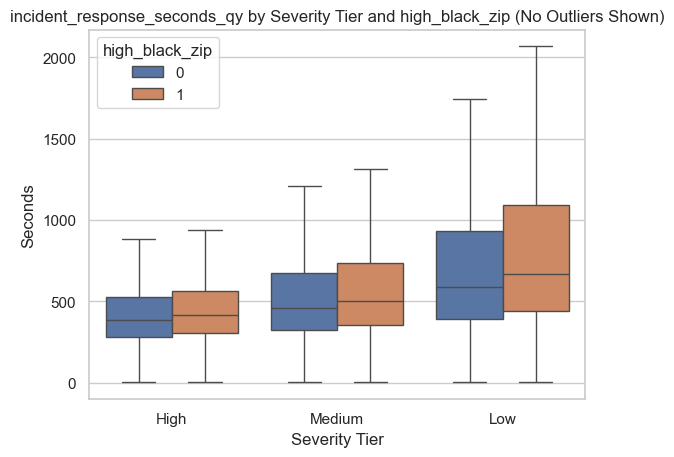

saved: ../outputs/figures/boxplot_no_outliers_incident_response_seconds_qy_high_black_zip.png


In [ ]:
os.makedirs("../outputs/figures", exist_ok=True)

sns.set_theme(style="whitegrid")

# boxplot (no outliers)
plt.figure()
sns.boxplot(
    data=df_valid,
    x="severity_tier",
    y=OUTCOME_COL,
    hue=group_col,
    order=["High", "Medium", "Low"],
    showfliers=False
)
plt.title(f"{OUTCOME_COL} by Severity Tier and {group_col} (No Outliers Shown)")
plt.xlabel("Severity Tier")
plt.ylabel("Seconds")
plt.legend(title=group_col)

fig1_out = f"../outputs/figures/boxplot_no_outliers_{OUTCOME_COL}_{group_col}.png"
plt.savefig(fig1_out, bbox_inches="tight", dpi=200)
plt.show()
plt.close()
print("saved:", fig1_out)

The boxplot shows that within each severity tier, response times are generally higher in high-Black ZIP codes compared to low-Black ZIP codes. The gap appears largest in the Low severity tier, indicating that disparities increase as severity decreases.

/var/folders/9j/gxbdb7ks5ts7m6x5msbhgckc0000gn/T/ipykernel_89633/167182222.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_valid.groupby(["severity_tier", group_col])[OUTCOME_COL]


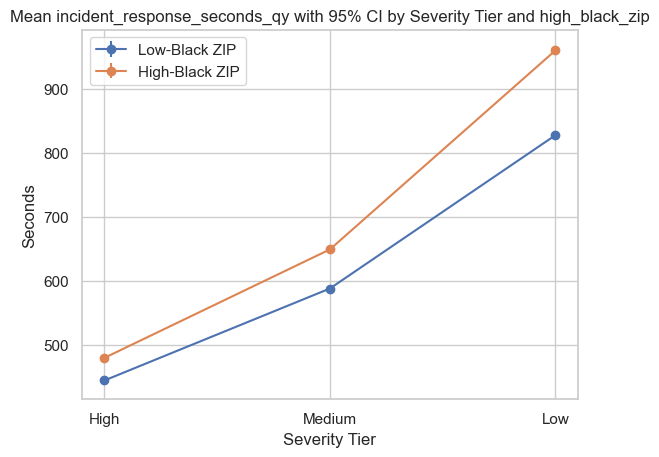

saved: ../outputs/figures/mean_ci_incident_response_seconds_qy_high_black_zip.png


In [ ]:
order = ["High", "Medium", "Low"]
df_valid["severity_tier"] = pd.Categorical(df_valid["severity_tier"], categories=order, ordered=True)

# mean + 95% CI lines
plt.figure()

means = (
    df_valid.groupby(["severity_tier", group_col])[OUTCOME_COL]
    .agg(mean="mean", n="count", std="std")
    .reset_index()
)

means["se"] = means["std"] / np.sqrt(means["n"])
means["ci95"] = 1.96 * means["se"]

for g in sorted(df_valid[group_col].unique()):
    sub = means[means[group_col] == g].set_index("severity_tier").reindex(order)
    label = "Low-Black ZIP" if g == 0 else "High-Black ZIP"
    plt.errorbar(sub.index, sub["mean"], yerr=sub["ci95"], fmt="o-", label=label)

plt.title(f"Mean {OUTCOME_COL} with 95% CI by Severity Tier and {group_col}")
plt.xlabel("Severity Tier")
plt.ylabel("Seconds")
plt.legend()

fig2_out = f"../outputs/figures/mean_ci_{OUTCOME_COL}_{group_col}.png"
plt.savefig(fig2_out, bbox_inches="tight", dpi=200)
plt.show()
plt.close()
print("saved:", fig2_out)

This plot shows the average response time with 95% confidence intervals. High-Black ZIP codes consistently have longer response times, and the difference becomes larger for lower severity calls.

In [ ]:
# save output tables (high_black_zip)
os.makedirs("../outputs/tables", exist_ok=True)

summary_out = "../outputs/tables/conditional_summary_by_tier_high_black_zip.csv"
tests_out = "../outputs/tables/pairwise_tests_by_tier_high_black_zip.csv"
diff_out = "../outputs/tables/mean_median_differences_by_tier_high_black_zip.csv"

summary.to_csv(summary_out, index=False)
tests_by_tier.to_csv(tests_out, index=False)
diff.reset_index().to_csv(diff_out, index=False)

print("saved:", summary_out)
print("saved:", tests_out)
print("saved:", diff_out)

saved: ../outputs/tables/conditional_summary_by_tier_high_black_zip.csv
saved: ../outputs/tables/pairwise_tests_by_tier_high_black_zip.csv
saved: ../outputs/tables/mean_median_differences_by_tier_high_black_zip.csv


In [ ]:
# proxy group: income_q
group_col = "income_q"

# conditional summary within severity tiers by income quartile
summary = (
    df_valid
    .groupby(["severity_tier", group_col])[OUTCOME_COL]
    .agg(n="count", mean="mean", median="median", std="std")
    .reset_index()
)

summary

/var/folders/9j/gxbdb7ks5ts7m6x5msbhgckc0000gn/T/ipykernel_89633/4181936189.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["severity_tier", group_col])[OUTCOME_COL]


,severity_tier,income_q,n,mean,median,std
0,High,Q1_low,22117,475.389339,408.0,357.301888
1,High,Q2,22031,466.444238,399.0,345.022544
2,High,Q3,21676,457.828981,406.0,287.668062
3,High,Q4_high,20012,445.586898,385.0,323.015122
4,Medium,Q1_low,28797,653.998264,499.0,579.019116
5,Medium,Q2,30190,623.800132,476.0,542.950808
6,Medium,Q3,31032,582.886375,473.0,446.816069
7,Medium,Q4_high,32044,594.812726,460.0,514.083208
8,Low,Q1_low,40117,990.839619,664.0,975.126174
9,Low,Q2,37253,920.881754,640.0,885.062271


Lower-income ZIP codes tend to have higher response times within each severity tier, with the largest gap appearing in the Low severity tier.

In [ ]:
# mean difference (Q1 - Q4) within each severity tier
pivot_income = summary.pivot(
    index="severity_tier",
    columns="income_q",
    values="mean"
)

income_diff = pd.DataFrame({
    "mean_difference_Q1_low_minus_Q4_high_sec":
        pivot_income["Q1_low"] - pivot_income["Q4_high"]
})

income_diff

,mean_difference_Q1_low_minus_Q4_high_sec
severity_tier,
High,29.802441
Medium,59.185537
Low,140.148573


In [ ]:
# ANOVA across all 4 income quartiles within each severity tier
group_col = "income_q"
income_order = ["Q1_low", "Q2", "Q3", "Q4_high"]

rows = []

for tier in ["High", "Medium", "Low"]:
    sub = df_valid[df_valid["severity_tier"] == tier]

    groups = [
        sub[sub[group_col] == q][OUTCOME_COL]
        for q in income_order
    ]

    f_stat, f_p = f_oneway(*groups)

    rows.append({
        "severity_tier": tier,
        "anova_p_value": f_p
    })

income_anova_by_tier = pd.DataFrame(rows)
income_anova_by_tier

,severity_tier,anova_p_value
0,High,3.970286e-20
1,Medium,8.311508e-72
2,Low,2.790289e-218


The ANOVA results confirm that response times vary across income quartiles within each severity tier. Combined with the summary table, this indicates that lower-income ZIP codes tend to experience longer response times.

In [ ]:
# interpretable two-group comparison (Q1 vs Q4) within each severity tier
rows = []

for tier in ["High", "Medium", "Low"]:
    sub = df_valid[df_valid["severity_tier"] == tier]

    x_low = sub[sub["income_q"] == "Q1_low"][OUTCOME_COL]
    x_high = sub[sub["income_q"] == "Q4_high"][OUTCOME_COL]

    t_stat, t_p, u_stat, u_p = run_tests(x_low, x_high)

    rows.append({
        "severity_tier": tier,
        "n_Q1_low": x_low.shape[0],
        "n_Q4_high": x_high.shape[0],
        "mean_Q1_low": x_low.mean(),
        "mean_Q4_high": x_high.mean(),
        "mean_diff_Q1_minus_Q4_sec": x_low.mean() - x_high.mean(),
        "welch_ttest_p_value": t_p
    })

income_pairwise = pd.DataFrame(rows)
income_pairwise

,severity_tier,n_Q1_low,n_Q4_high,mean_Q1_low,mean_Q4_high,mean_diff_Q1_minus_Q4_sec,welch_ttest_p_value
0,High,22117,20012,475.389339,445.586898,29.802441,2.538069e-19
1,Medium,28797,32044,653.998264,594.812726,59.185537,3.907677e-40
2,Low,40117,36766,990.839619,850.691046,140.148573,2.731406e-102


/var/folders/9j/gxbdb7ks5ts7m6x5msbhgckc0000gn/T/ipykernel_89633/1150756834.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_valid.groupby(["severity_tier", group_col])[OUTCOME_COL]


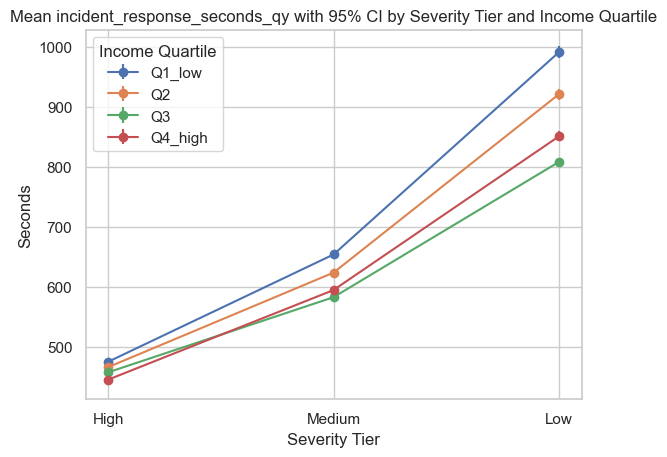

saved: ../outputs/figures/mean_ci_incident_response_seconds_qy_income_q.png


In [ ]:
group_col = "income_q"
order = ["High", "Medium", "Low"]
income_order = ["Q1_low", "Q2", "Q3", "Q4_high"]

df_valid["severity_tier"] = pd.Categorical(
    df_valid["severity_tier"], categories=order, ordered=True
)

# mean + 95% CI lines by income quartile
plt.figure()

means_income = (
    df_valid.groupby(["severity_tier", group_col])[OUTCOME_COL]
    .agg(mean="mean", n="count", std="std")
    .reset_index()
)

means_income["se"] = means_income["std"] / np.sqrt(means_income["n"])
means_income["ci95"] = 1.96 * means_income["se"]

for q in income_order:
    sub = means_income[means_income[group_col] == q] \
        .set_index("severity_tier") \
        .reindex(order)

    plt.errorbar(
        sub.index,
        sub["mean"],
        yerr=sub["ci95"],
        fmt="o-",
        label=q
    )

plt.title(f"Mean {OUTCOME_COL} with 95% CI by Severity Tier and Income Quartile")
plt.xlabel("Severity Tier")
plt.ylabel("Seconds")
plt.legend(title="Income Quartile")

fig_out = f"../outputs/figures/mean_ci_{OUTCOME_COL}_income_q.png"
plt.savefig(fig_out, bbox_inches="tight", dpi=200)
plt.show()
plt.close()

print("saved:", fig_out)

The plot shows a clear pattern: lower-income ZIP codes (Q1) consistently have higher average response times than higher-income ZIP codes (Q4) within each severity tier. The gap becomes much larger in the Low severity tier, indicating that income-related disparities are strongest for lower-priority calls.

In [89]:
summary_income_out = "../outputs/tables/conditional_summary_by_tier_income_q.csv"
anova_income_out = "../outputs/tables/anova_tests_by_tier_income_q.csv"
pairwise_income_out = "../outputs/tables/pairwise_q1_vs_q4_tests_by_tier_income_q.csv"

# save files
summary.to_csv(summary_income_out, index=False)
income_anova_by_tier.to_csv(anova_income_out, index=False)
income_pairwise.to_csv(pairwise_income_out, index=False)

print("saved:", summary_income_out)
print("saved:", anova_income_out)
print("saved:", pairwise_income_out)

saved: ../outputs/tables/conditional_summary_by_tier_income_q.csv
saved: ../outputs/tables/anova_tests_by_tier_income_q.csv
saved: ../outputs/tables/pairwise_q1_vs_q4_tests_by_tier_income_q.csv
